# Layer 1 Baseline + Multi-Year Extension

Baseline predictive check: can **2020 Sentinel indices** separate **paved vs unpaved** roads?

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repo root named {repo_name!r} from {start}")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
S2_2020_DIR = DATA_DIR / "ghana_parquet_s1" / "year=2020"

# Prefer the latest PBF present in data/
pbf_candidates = sorted(DATA_DIR.glob("*.osm.pbf"))
PBF_PATH = pbf_candidates[-1] if pbf_candidates else None

print("Repo root:", ROOT)
print("Data dir:", DATA_DIR)
print("2020 parquet dir exists:", S2_2020_DIR.exists())
print("PBF:", PBF_PATH if PBF_PATH else "(not found)")

from sklearn.metrics import matthews_corrcoef
from scipy.stats import wilcoxon

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception:
    lgbm_available = False
    print('LightGBM not installed; run: pip install lightgbm')


Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP
Data dir: /Users/miranda/Documents/GitHub/Sentinel-FYP/data
2020 parquet dir exists: True
PBF: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260415.osm.pbf


## 1) Load 2020 Sentinel Features

In [5]:
if not S2_2020_DIR.exists():
    raise FileNotFoundError(f"Missing directory: {S2_2020_DIR}")

parquet_files = sorted(S2_2020_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {S2_2020_DIR}")

# Keep behavior stable with project convention: first file per year
s2_2020 = pd.read_parquet(parquet_files[0]).copy()
s2_2020["osm_id"] = s2_2020["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
s1_cols = ["s1_vv_mean", "s1_vh_mean", "s1_vv_minus_vh_mean", "s1_vv_std", "s1_vh_std", "s1_vv_minus_vh_std"]
s1_cols_present = [c for c in s1_cols if c in s2_2020.columns]

for c in idx_cols + s1_cols_present:
    s2_2020[c] = pd.to_numeric(s2_2020[c], errors="coerce")

# keep rows with any S2 or S1 signal present
s2_2020 = s2_2020.dropna(subset=idx_cols + s1_cols_present, how="all").copy()

print("2020 rows:", len(s2_2020))
print("2020 unique osm_id:", s2_2020["osm_id"].nunique())
s2_2020.head(3)




2020 rows: 1487200
2020 unique osm_id: 371800


,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI,s1_vv_mean,s1_vh_mean,s1_vv_minus_vh_mean,s1_vv_std,s1_vh_std,s1_vv_minus_vh_std
0,1000042059,<NA>,Q1,NaN,NaN,NaN,NaN,NaN,-13.329946,-20.773765,7.443818,1.547009,1.465495,0.890763
1,1000042059,<NA>,Q2,NaN,NaN,NaN,NaN,NaN,-11.645346,-18.523746,6.878400,1.331531,1.528828,0.794967
2,1000042059,<NA>,Q3,NaN,NaN,NaN,NaN,NaN,-9.690929,-16.373377,6.682448,0.923411,0.787408,0.797242


## 2) Build OSM Paved/Unpaved Labels (Large Label Inventory)


In [6]:
try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required for this section. Install with: pip install pyrosm") from e

if PBF_PATH is None or not PBF_PATH.exists():
    raise FileNotFoundError("No .osm.pbf file found in data/")

osm = OSM(str(PBF_PATH))
roads_osm = osm.get_network(network_type="driving").copy()

# Normalize keys/fields
roads_osm["osm_id"] = roads_osm["id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
roads_osm["surface_clean"] = roads_osm["surface"].astype(str).str.lower().str.strip()
roads_osm["road_name_clean"] = roads_osm.get("name", pd.Series(index=roads_osm.index, dtype="object")).astype(str).str.strip()
roads_osm.loc[roads_osm["road_name_clean"].isin(["", "nan", "None"]), "road_name_clean"] = np.nan

focus_classes = ["residential", "service", "trunk", "primary", "secondary", "tertiary", "unclassified"]
roads_osm = roads_osm[roads_osm["highway"].isin(focus_classes)].copy()

paved_vals = {"paved", "asphalt", "concrete", "paving_stones", "concrete:plates", "sett", "cobblestone", "metal", "bricks", "cement", "chipseal"}
unpaved_vals = {"unpaved", "ground", "dirt", "earth", "gravel", "fine_gravel", "sand", "mud", "grass", "compacted", "pebblestone", "soil"}

# Direct label from OSM surface where available
roads_osm["layer1_label_large"] = np.where(
    roads_osm["surface_clean"].isin(paved_vals), "paved",
    np.where(roads_osm["surface_clean"].isin(unpaved_vals), "unpaved", None)
)

# Propagate missing labels by road name only when the name has one unambiguous known class.
name_known = roads_osm.dropna(subset=["road_name_clean", "layer1_label_large"]).copy()
name_stats = (
    name_known.groupby("road_name_clean")["layer1_label_large"]
    .agg(lambda s: sorted(set(s.dropna().tolist())))
    .to_frame("classes")
)
name_stats["n_classes"] = name_stats["classes"].apply(len)
name_stats["inferred_label"] = np.where(
    name_stats["n_classes"] == 1,
    name_stats["classes"].apply(lambda x: x[0]),
    np.nan,
)
name_to_label = name_stats["inferred_label"].dropna()

missing_before = roads_osm["layer1_label_large"].isna().sum()
fill_mask = roads_osm["layer1_label_large"].isna() & roads_osm["road_name_clean"].notna()
roads_osm.loc[fill_mask, "layer1_label_large"] = roads_osm.loc[fill_mask, "road_name_clean"].map(name_to_label)
missing_after = roads_osm["layer1_label_large"].isna().sum()
filled_count = missing_before - missing_after

label_df_large = roads_osm[["osm_id", "highway", "layer1_label_large"]].copy()
label_df_large = label_df_large[label_df_large["layer1_label_large"].isin(["paved", "unpaved"])].drop_duplicates(subset=["osm_id"])
label_df_large = label_df_large.rename(columns={"highway": "fclass"})

print("PBF used:", PBF_PATH.name)
print("Named-road propagation candidates:", int(fill_mask.sum()))
print("Named-road labels filled:", int(filled_count))
print("Large label rows:", len(label_df_large))
print("Large label unique osm_id:", label_df_large["osm_id"].nunique())
print("Large label balance (%):")
print(label_df_large["layer1_label_large"].value_counts(normalize=True).mul(100).round(2))



/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


PBF used: ghana-260415.osm.pbf
Named-road propagation candidates: 10140
Named-road labels filled: 1784
Large label rows: 31650
Large label unique osm_id: 31650
Large label balance (%):
layer1_label_large
unpaved    54.61
paved      45.39
Name: proportion, dtype: float64


## 3) Merge Labels with 2020 S2 and Aggregate Road Features

In [7]:
df_q_large = s2_2020.merge(label_df_large[["osm_id", "layer1_label_large"]], on="osm_id", how="inner")

print("Quarterly merged rows:", len(df_q_large))
print("Quarterly unique roads:", df_q_large["osm_id"].nunique())

# Build dynamic aggregation (S2 + available S1)
agg_kwargs = {
    "NDVI_mean": ("NDVI", "mean"), "NDVI_std": ("NDVI", "std"),
    "NDMI_mean": ("NDMI", "mean"), "NDMI_std": ("NDMI", "std"),
    "NDBI_mean": ("NDBI", "mean"), "NDBI_std": ("NDBI", "std"),
    "NDWI_mean": ("NDWI", "mean"), "NDWI_std": ("NDWI", "std"),
    "BSI_mean":  ("BSI",  "mean"), "BSI_std":  ("BSI",  "std"),
}

s1_cols = ["s1_vv_mean", "s1_vh_mean", "s1_vv_minus_vh_mean", "s1_vv_std", "s1_vh_std", "s1_vv_minus_vh_std"]
s1_cols_present = [c for c in s1_cols if c in df_q_large.columns]
for sc in s1_cols_present:
    agg_kwargs[f"{sc}_mean"] = (sc, "mean")
    agg_kwargs[f"{sc}_std"] = (sc, "std")

road_feats_large = (
    df_q_large.groupby(["osm_id", "layer1_label_large"], as_index=False)
    .agg(**agg_kwargs)
)

feat_cols = [c for c in road_feats_large.columns if c not in ["osm_id", "layer1_label_large"]]
road_feats_large[feat_cols] = road_feats_large[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print("Road-level rows:", len(road_feats_large))
road_feats_large.head(3)




Quarterly merged rows: 125052
Quarterly unique roads: 31263
Road-level rows: 31263


,osm_id,layer1_label_large,NDVI_mean,NDVI_std,NDMI_mean,NDMI_std,NDBI_mean,NDBI_std,NDWI_mean,NDWI_std,BSI_mean,BSI_std,s1_vv_mean_mean,s1_vv_mean_std,s1_vh_mean_mean,s1_vh_mean_std,s1_vv_minus_vh_mean_mean,s1_vv_minus_vh_mean_std,s1_vv_std_mean,s1_vv_std_std,s1_vh_std_mean,s1_vh_std_std,s1_vv_minus_vh_std_mean,s1_vv_minus_vh_std_std
0,1000593771,unpaved,0.462907,0.126340,0.001337,0.079725,-0.001337,0.079725,-0.450826,0.101675,0.023422,0.068220,-10.199717,0.551738,-16.751295,0.371976,6.551578,0.201787,1.431669,0.128087,1.626089,0.100372,1.148768,0.042003
1,1000593772,unpaved,0.476908,0.132937,-0.008550,0.081132,0.008550,0.081132,-0.448421,0.100167,0.027232,0.068157,-10.278471,0.582285,-16.661889,0.399121,6.383418,0.231136,1.010143,0.111728,1.239763,0.183496,1.115665,0.182364
2,1000593776,unpaved,0.471026,0.111829,-0.012013,0.066428,0.012013,0.066428,-0.459972,0.093740,0.036927,0.054628,-10.384778,0.477054,-16.871297,0.466353,6.486519,0.157837,1.526398,0.115954,1.619233,0.095695,1.186755,0.091066


## 4) Train Baseline RandomForest

Layer-1 report:
              precision    recall  f1-score   support

       paved      0.788     0.760     0.774      2833
     unpaved      0.807     0.831     0.818      3420

    accuracy                          0.798      6253
   macro avg      0.797     0.795     0.796      6253
weighted avg      0.798     0.798     0.798      6253



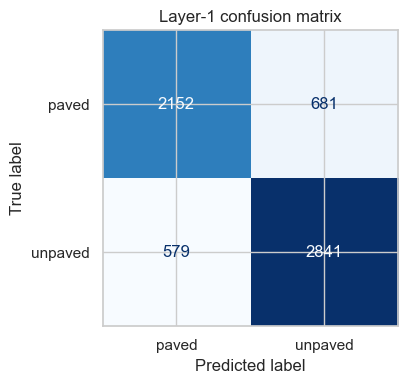

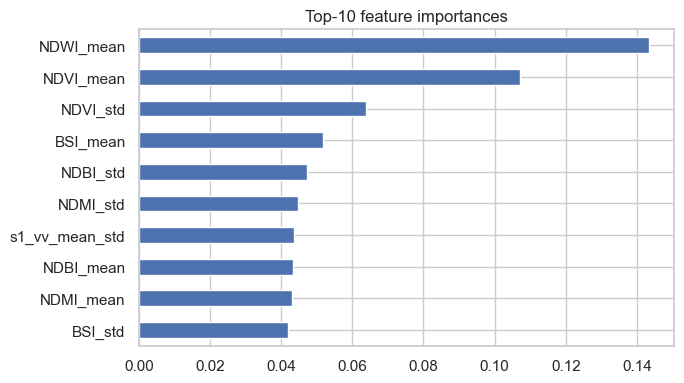

In [8]:
X = road_feats_large[feat_cols].copy()
y = road_feats_large["layer1_label_large"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Layer-1 report:")
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=["paved", "unpaved"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["paved", "unpaved"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Layer-1 confusion matrix")
plt.tight_layout()
plt.show()

imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
imp.head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-10 feature importances")
plt.tight_layout()
plt.show()



## Notes
- This is a baseline add-on experiment with larger OSM-derived labels.
- Next step is extension to 2020–2023 with stronger controls and validation labels.

## 5) Multi-Year Extension (2020-2023)

Build a broader S2 feature set from all available years:
- Year-specific index means (`*_mean_y2020 ... *_mean_y2023`)
- Year-specific index std (`*_std_yYYYY`)
- Year-over-year delta (`*_delta_2023_2020`)
- Linear trend slope across years (`*_slope_year`)

Then train a second RandomForest and compare against the 2020 baseline.


In [9]:
# ---- Multi-year S2 + S1 loader ----
idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
s1_cols = ["s1_vv_mean", "s1_vh_mean", "s1_vv_minus_vh_mean", "s1_vv_std", "s1_vh_std", "s1_vv_minus_vh_std"]
YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023]

# Filter to labeled roads at load time — identical to the inner join done later,
# but avoids holding 8M+ unlabeled rows in RAM across all years.
labeled_ids = set(label_df_large["osm_id"].astype(str))


def read_year_frames(year: int, base_dir: Path) -> pd.DataFrame:
    year_dir = base_dir / f"year={year}"
    if not year_dir.exists():
        raise FileNotFoundError(f"Missing year directory: {year_dir}")

    files = sorted(year_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files in: {year_dir}")

    frames = []
    errors = []
    for f in files:
        try:
            temp = pd.read_parquet(f).copy()
            frames.append(temp)
        except Exception as e:
            errors.append((f.name, str(e)))

    if not frames:
        msg = "\n".join([f" - {name}: {err[:180]}" for name, err in errors])
        raise RuntimeError(f"Could not read any parquet files for year={year}.\n{msg}")

    out = pd.concat(frames, ignore_index=True)
    out["year"] = year
    return out


multi_frames = []
for y in YEARS:
    yf = read_year_frames(y, DATA_DIR / "ghana_parquet_s1")
    yf["osm_id"] = yf["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    yf = yf[yf["osm_id"].isin(labeled_ids)]
    for c in idx_cols + s1_cols:
        if c in yf.columns:
            yf[c] = pd.to_numeric(yf[c], errors="coerce")
    yf = yf.dropna(subset=idx_cols, how="all")
    present_s1 = [c for c in s1_cols if c in yf.columns]
    multi_frames.append(yf[["osm_id", "quarter", "year", *idx_cols, *present_s1]])

s2_multi = pd.concat(multi_frames, ignore_index=True)
s1_cols_present = [c for c in s1_cols if c in s2_multi.columns]

print("Multi-year rows:", len(s2_multi))
print("Unique roads:", s2_multi["osm_id"].nunique())
print("Years present:", sorted(s2_multi["year"].dropna().unique().tolist()))
print("S1 columns present:", s1_cols_present)
s2_multi.head(3)


Multi-year rows: 631461
Unique roads: 30851
Years present: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
S1 columns present: ['s1_vv_mean', 's1_vh_mean', 's1_vv_minus_vh_mean', 's1_vv_std', 's1_vh_std', 's1_vv_minus_vh_std']


,osm_id,quarter,year,NDVI,NDMI,NDBI,NDWI,BSI,s1_vv_mean,s1_vh_mean,s1_vv_minus_vh_mean,s1_vv_std,s1_vh_std,s1_vv_minus_vh_std
0,1000593771,Q1,2017,0.432658,-0.050048,0.050048,-0.473293,0.090256,-10.797699,-16.191207,5.393508,1.574338,1.605145,1.197289
1,1000593772,Q1,2017,0.448968,-0.057011,0.057011,-0.486465,0.094579,-11.329064,-16.932653,5.603589,1.349977,1.486363,1.011277
2,1000593776,Q1,2017,0.436521,-0.052368,0.052368,-0.483197,0.095698,-11.350022,-16.761339,5.411317,1.450025,1.666130,1.326109


Merged multi-year quarterly rows: 631461
Merged unique roads: 30851
Multi-year road-level rows: 30851
Feature count: 176

Layer-1 multi-year report:
              precision    recall  f1-score   support

       paved      0.858     0.815     0.836      2766
     unpaved      0.855     0.890     0.873      3405

    accuracy                          0.856      6171
   macro avg      0.857     0.852     0.854      6171
weighted avg      0.856     0.856     0.856      6171



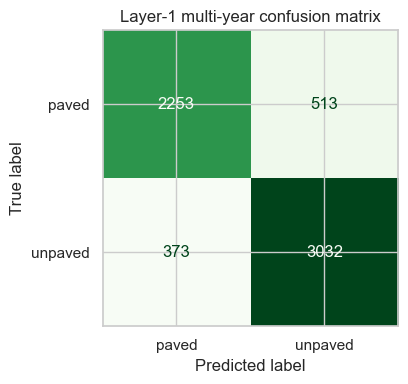

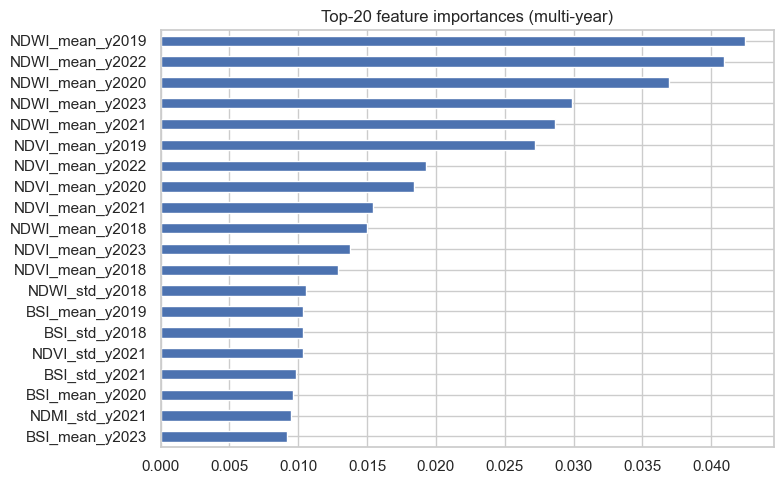

Top-15 important features:


,importance
NDWI_mean_y2019,0.042442
NDWI_mean_y2022,0.040967
NDWI_mean_y2020,0.036947
NDWI_mean_y2023,0.029858
NDWI_mean_y2021,0.028631
NDVI_mean_y2019,0.027222
NDVI_mean_y2022,0.019286
NDVI_mean_y2020,0.018399
NDVI_mean_y2021,0.015422
NDWI_mean_y2018,0.014987


In [10]:
# ---- Build multi-year road features + train second RF ----
df_q_multi = s2_multi.merge(
    label_df_large[["osm_id", "layer1_label_large"]],
    on="osm_id",
    how="inner",
)

print("Merged multi-year quarterly rows:", len(df_q_multi))
print("Merged unique roads:", df_q_multi["osm_id"].nunique())

# 1) Aggregate per road+label+year (S2 + S1)
agg_kwargs = {
    "NDVI_mean": ("NDVI", "mean"), "NDVI_std": ("NDVI", "std"),
    "NDMI_mean": ("NDMI", "mean"), "NDMI_std": ("NDMI", "std"),
    "NDBI_mean": ("NDBI", "mean"), "NDBI_std": ("NDBI", "std"),
    "NDWI_mean": ("NDWI", "mean"), "NDWI_std": ("NDWI", "std"),
    "BSI_mean":  ("BSI",  "mean"), "BSI_std":  ("BSI",  "std"),
}
for sc in s1_cols_present:
    agg_kwargs[f"{sc}_mean"] = (sc, "mean")
    agg_kwargs[f"{sc}_std"]  = (sc, "std")

road_year = df_q_multi.groupby(["osm_id", "layer1_label_large", "year"], as_index=False).agg(**agg_kwargs)

# 2) Pivot to wide format by year
s2_mean_cols = ["NDVI_mean", "NDMI_mean", "NDBI_mean", "NDWI_mean", "BSI_mean"]
s2_std_cols  = ["NDVI_std",  "NDMI_std",  "NDBI_std",  "NDWI_std",  "BSI_std"]
s1_mean_cols = [f"{sc}_mean" for sc in s1_cols_present]
s1_std_cols  = [f"{sc}_std"  for sc in s1_cols_present]

all_mean_cols = s2_mean_cols + s1_mean_cols
all_std_cols  = s2_std_cols  + s1_std_cols

means_wide = road_year.pivot(index=["osm_id", "layer1_label_large"], columns="year", values=all_mean_cols)
std_wide   = road_year.pivot(index=["osm_id", "layer1_label_large"], columns="year", values=all_std_cols)
means_wide.columns = [f"{m}_y{y}" for (m, y) in means_wide.columns]
std_wide.columns   = [f"{m}_y{y}" for (m, y) in std_wide.columns]

road_multi = pd.concat([means_wide, std_wide], axis=1).reset_index()

# 3) Delta and slope for each mean feature (S2 + S1)
for feat_base in all_mean_cols:
    y20 = f"{feat_base}_y2020"
    y21 = f"{feat_base}_y2021"
    y22 = f"{feat_base}_y2022"
    y23 = f"{feat_base}_y2023"

    if all(c in road_multi.columns for c in [y20, y21, y22, y23]):
        road_multi[f"{feat_base}_delta_2023_2020"] = road_multi[y23] - road_multi[y20]

        def slope4(row, _y20=y20, _y21=y21, _y22=y22, _y23=y23):
            vals = np.array([row[_y20], row[_y21], row[_y22], row[_y23]], dtype=float)
            mask = ~np.isnan(vals)
            if mask.sum() < 3:
                return np.nan
            x = np.arange(4)[mask]
            return np.polyfit(x, vals[mask], 1)[0]

        road_multi[f"{feat_base}_slope_year"] = road_multi.apply(slope4, axis=1)

# Fill missing
num_cols = [c for c in road_multi.columns if c not in ["osm_id", "layer1_label_large"]]
road_multi[num_cols] = road_multi[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print("Multi-year road-level rows:", len(road_multi))
print("Feature count:", len(num_cols))

X2 = road_multi[num_cols].copy()
y2 = road_multi["layer1_label_large"].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

rf_multi = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_multi.fit(X2_train, y2_train)
pred2 = rf_multi.predict(X2_test)
proba2 = rf_multi.predict_proba(X2_test)

print("\nLayer-1 multi-year report:")
print(classification_report(y2_test, pred2, digits=3))

cm2 = confusion_matrix(y2_test, pred2, labels=["paved", "unpaved"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm2, display_labels=["paved", "unpaved"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Layer-1 multi-year confusion matrix")
plt.tight_layout()
plt.show()

imp2 = pd.Series(rf_multi.feature_importances_, index=num_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
imp2.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-20 feature importances (multi-year)")
plt.tight_layout()
plt.show()

print("Top-15 important features:")
display(imp2.head(15).to_frame("importance"))


## Multi-Year Interpretation Checklist

- Compare baseline vs multi-year confusion matrix and class-wise precision/recall.
- If multi-year improves unpaved recall, it likely captures persistent surface context + temporal change.
- Inspect whether `*_delta_2023_2020` or `*_slope_year` appears among top features; if yes, temporal signal is contributing beyond static yearly means.


## 6) Enhanced Temporal Feature Pack + RandomForest (No Logistic)

Adds richer temporal features from quarterly 2020-2023 signals, then retrains RF for comparison.

Enhanced temporal RF report:
              precision    recall  f1-score   support

       paved      0.858     0.815     0.836      2766
     unpaved      0.855     0.890     0.872      3405

    accuracy                          0.856      6171
   macro avg      0.856     0.852     0.854      6171
weighted avg      0.856     0.856     0.856      6171



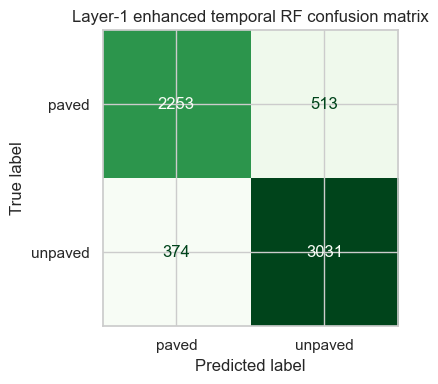

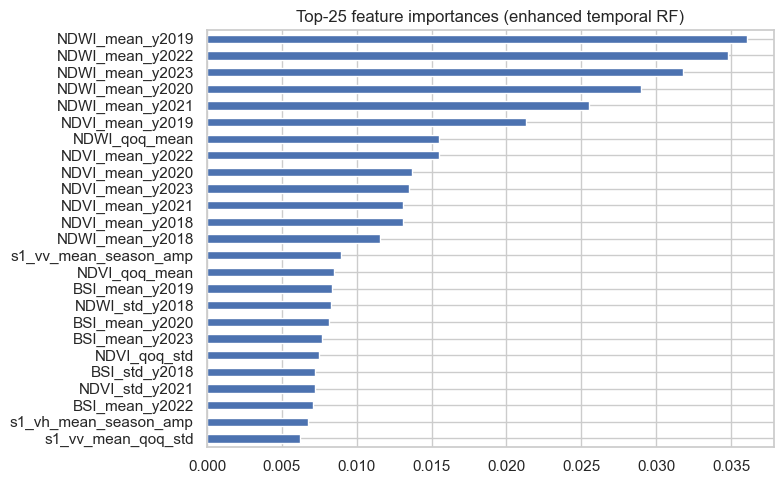

Top-20 important features (enhanced temporal RF):


,importance
NDWI_mean_y2019,0.036068
NDWI_mean_y2022,0.034797
NDWI_mean_y2023,0.031801
NDWI_mean_y2020,0.028997
NDWI_mean_y2021,0.025546
NDVI_mean_y2019,0.021329
NDWI_qoq_mean,0.015510
NDVI_mean_y2022,0.015481
NDVI_mean_y2020,0.013716
NDVI_mean_y2023,0.013501


Feature count (enhanced): 256


In [11]:
# ---- Enhanced temporal feature engineering from quarterly series ----
# Uses df_q_multi from section 5 (merged quarterly S2 + S1 + labels).

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
quarter_order = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}

tmp = df_q_multi.copy()
tmp["q_num"] = tmp["quarter"].map(quarter_order)
tmp = tmp.dropna(subset=["q_num"]).copy()
tmp["time_idx"] = (tmp["year"] - tmp["year"].min()) * 4 + (tmp["q_num"] - 1)

group_keys = ["osm_id", "layer1_label_large"]

# Start from existing multi-year feature table to keep comparability.
rf_temporal = road_multi.copy()


def add_series_features(base_df, signal_name):
    s = tmp[group_keys + ["time_idx", "q_num", signal_name]].dropna(subset=[signal_name]).copy()

    # linear slope over all quarters
    def slope_fn(g):
        if len(g) < 4:
            return np.nan
        x = g["time_idx"].to_numpy(dtype=float)
        y = g[signal_name].to_numpy(dtype=float)
        if np.all(np.isclose(y, y[0])):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    slope = s.groupby(group_keys, as_index=False).apply(slope_fn, include_groups=False)
    slope = slope.rename(columns={None: f"{signal_name}_slope_q"})

    # quarter-to-quarter diffs
    s = s.sort_values(group_keys + ["time_idx"])
    s["diff"] = s.groupby(group_keys)[signal_name].diff()

    qoq_stats = s.groupby(group_keys, as_index=False).agg(
        **{
            f"{signal_name}_qoq_mean": ("diff", "mean"),
            f"{signal_name}_qoq_std": ("diff", "std"),
            f"{signal_name}_qoq_max_rise": ("diff", "max"),
            f"{signal_name}_qoq_max_drop": ("diff", "min"),
        }
    )

    # seasonality: wet vs dry contrast proxy (Q2/Q3 vs Q1/Q4)
    season = s.groupby(group_keys + ["q_num"], as_index=False)[signal_name].mean()
    season_p = season.pivot(index=group_keys, columns="q_num", values=signal_name)
    season_p.columns = [f"q{int(c)}" for c in season_p.columns]
    season_p = season_p.reset_index()

    for q in [1, 2, 3, 4]:
        c = f"q{q}"
        if c not in season_p.columns:
            season_p[c] = np.nan

    season_p[f"{signal_name}_wet_dry_delta"] = season_p[["q2", "q3"]].mean(axis=1) - season_p[["q1", "q4"]].mean(axis=1)
    season_p[f"{signal_name}_season_amp"] = season_p[["q1", "q2", "q3", "q4"]].max(axis=1) - season_p[["q1", "q2", "q3", "q4"]].min(axis=1)

    keep_cols = group_keys + [
        f"{signal_name}_wet_dry_delta",
        f"{signal_name}_season_amp",
    ]
    season_feats = season_p[keep_cols]

    out = base_df.merge(slope, on=group_keys, how="left")
    out = out.merge(qoq_stats, on=group_keys, how="left")
    out = out.merge(season_feats, on=group_keys, how="left")
    return out


# S2 temporal features
for idx in idx_cols:
    rf_temporal = add_series_features(rf_temporal, idx)

# S1 temporal features
for sc in s1_cols_present:
    rf_temporal = add_series_features(rf_temporal, sc)

# Cross-index temporal interactions (simple but useful)
for a, b in [("NDBI", "NDVI"), ("BSI", "NDMI"), ("NDWI", "NDMI")]:
    ca = f"{a}_slope_q"
    cb = f"{b}_slope_q"
    if ca in rf_temporal.columns and cb in rf_temporal.columns:
        rf_temporal[f"{a}_{b}_slope_gap"] = rf_temporal[ca] - rf_temporal[cb]

# Final model table
feature_cols_temporal = [c for c in rf_temporal.columns if c not in ["osm_id", "layer1_label_large"]]
rf_temporal[feature_cols_temporal] = rf_temporal[feature_cols_temporal].apply(pd.to_numeric, errors="coerce").fillna(0)

X3 = rf_temporal[feature_cols_temporal].copy()
y3 = rf_temporal["layer1_label_large"].copy()

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

rf_temporal_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_temporal_model.fit(X3_train, y3_train)
pred3 = rf_temporal_model.predict(X3_test)

print("Enhanced temporal RF report:")
print(classification_report(y3_test, pred3, digits=3))

cm3 = confusion_matrix(y3_test, pred3, labels=["paved", "unpaved"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm3, display_labels=["paved", "unpaved"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Layer-1 enhanced temporal RF confusion matrix")
plt.tight_layout()
plt.show()

imp3 = pd.Series(rf_temporal_model.feature_importances_, index=feature_cols_temporal).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
imp3.head(25).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-25 feature importances (enhanced temporal RF)")
plt.tight_layout()
plt.show()

print("Top-20 important features (enhanced temporal RF):")
display(imp3.head(20).to_frame("importance"))
print("Feature count (enhanced):", len(feature_cols_temporal))


## 7) Graph Neighbors Context (Endpoint Adjacency) + RF

Build a road-segment graph where segments are neighbors if they share an endpoint. Add neighbor-aggregated multi-year+temporal features, then retrain RF.

Segments in graph scope: 30851
Segments with >=1 neighbor: 28482
Median degree: 2.0
Graph-neighbor enhanced RF report:
              precision    recall  f1-score   support

       paved      0.860     0.826     0.843      2766
     unpaved      0.863     0.891     0.877      3405

    accuracy                          0.862      6171
   macro avg      0.862     0.858     0.860      6171
weighted avg      0.862     0.862     0.861      6171



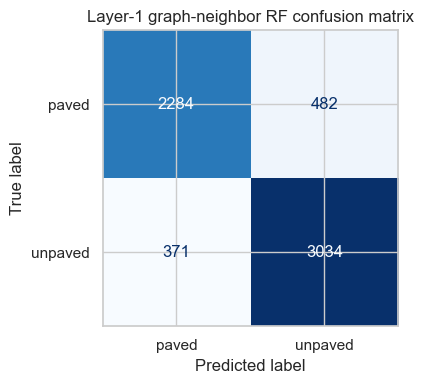

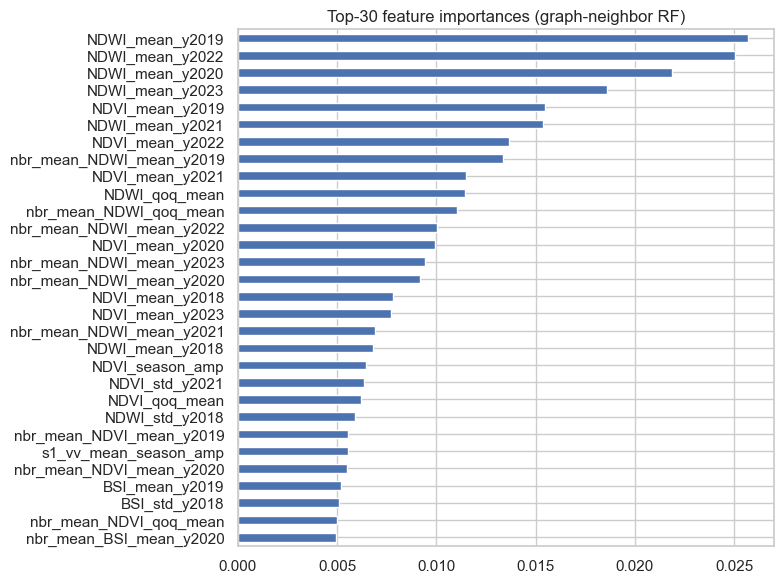

Top-20 important features (graph-neighbor RF):


,importance
NDWI_mean_y2019,0.025728
NDWI_mean_y2022,0.025025
NDWI_mean_y2020,0.021873
NDWI_mean_y2023,0.018606
NDVI_mean_y2019,0.015453
NDWI_mean_y2021,0.015388
NDVI_mean_y2022,0.013659
nbr_mean_NDWI_mean_y2019,0.013364
NDVI_mean_y2021,0.011486
NDWI_qoq_mean,0.011422


Feature count (graph-neighbor): 431


In [12]:
# ---- Graph neighbors from shared geometry endpoints ----
# Requires: roads_osm (with geometry), rf_temporal from section 6.

from collections import defaultdict

if 'geometry' not in roads_osm.columns:
    raise ValueError('roads_osm geometry missing; rerun section 2 first.')

# Keep only roads used in modeling to avoid leakage of unrelated rows
model_ids = set(rf_temporal['osm_id'].astype(str))
road_geom = roads_osm[roads_osm['osm_id'].astype(str).isin(model_ids)][['osm_id','geometry']].copy()
road_geom['osm_id'] = road_geom['osm_id'].astype(str)

# Endpoint extraction helper

def endpoints_of_geom(g):
    if g is None or g.is_empty:
        return []
    gt = g.geom_type
    pts = []
    if gt == 'LineString':
        coords = list(g.coords)
        if len(coords) >= 2:
            pts = [coords[0], coords[-1]]
    elif gt == 'MultiLineString':
        for part in g.geoms:
            coords = list(part.coords)
            if len(coords) >= 2:
                pts.extend([coords[0], coords[-1]])
    # rounding stabilizes floating precision noise in endpoint matching
    return [(round(x, 6), round(y, 6)) for x, y in pts]

# Build node -> segment index
node_to_ids = defaultdict(set)
for oid, geom in zip(road_geom['osm_id'], road_geom['geometry']):
    for node in endpoints_of_geom(geom):
        node_to_ids[node].add(oid)

# Build adjacency list
neighbors = defaultdict(set)
for ids in node_to_ids.values():
    if len(ids) < 2:
        continue
    ids_list = list(ids)
    for i in range(len(ids_list)):
        a = ids_list[i]
        for j in range(i+1, len(ids_list)):
            b = ids_list[j]
            neighbors[a].add(b)
            neighbors[b].add(a)

# Graph stats
degree_df = pd.DataFrame({
    'osm_id': rf_temporal['osm_id'].astype(str),
    'nbr_degree': rf_temporal['osm_id'].astype(str).map(lambda x: len(neighbors.get(x, set()))),
})

print('Segments in graph scope:', len(road_geom))
print('Segments with >=1 neighbor:', int((degree_df['nbr_degree'] > 0).sum()))
print('Median degree:', float(degree_df['nbr_degree'].median()))

# Neighbor feature aggregation from current temporal feature table
base = rf_temporal.copy()
base['osm_id'] = base['osm_id'].astype(str)
num_cols = [c for c in base.columns if c not in ['osm_id', 'layer1_label_large']]

# Priority subset: core S2 temporal + S1 temporal features for neighbor aggregation
priority = [c for c in num_cols if any(k in c for k in [
    'NDWI_mean_y', 'NDVI_mean_y', 'BSI_mean_y',
    's1_vv_mean_y', 's1_vh_mean_y', 's1_vv_minus_vh_mean_y',
    '_slope_q', '_qoq_mean', '_qoq_std', '_wet_dry_delta', '_season_amp',
    'delta_2023_2020'
])]
# fallback if filter is too small
if len(priority) < 20:
    priority = num_cols[:min(40, len(num_cols))]

feat_lookup = base.set_index('osm_id')[priority]

agg_rows = []
for oid in base['osm_id']:
    nbrs = list(neighbors.get(oid, set()))
    row = {'osm_id': oid}
    if nbrs:
        sub = feat_lookup.reindex(nbrs)
        for c in priority:
            row[f'nbr_mean_{c}'] = sub[c].mean(skipna=True)
            row[f'nbr_std_{c}'] = sub[c].std(skipna=True)
    else:
        for c in priority:
            row[f'nbr_mean_{c}'] = np.nan
            row[f'nbr_std_{c}'] = np.nan
    agg_rows.append(row)

nbr_feats = pd.DataFrame(agg_rows)

rf_graph = base.merge(degree_df, on='osm_id', how='left').merge(nbr_feats, on='osm_id', how='left')
rf_graph = rf_graph.fillna(0)

feature_cols_graph = [c for c in rf_graph.columns if c not in ['osm_id', 'layer1_label_large']]

Xg = rf_graph[feature_cols_graph].copy()
yg = rf_graph['layer1_label_large'].copy()

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42, stratify=yg
)

rf_graph_model = RandomForestClassifier(
    n_estimators=900,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
)
rf_graph_model.fit(Xg_train, yg_train)
predg = rf_graph_model.predict(Xg_test)

print('Graph-neighbor enhanced RF report:')
print(classification_report(yg_test, predg, digits=3))

cmg = confusion_matrix(yg_test, predg, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cmg, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Layer-1 graph-neighbor RF confusion matrix')
plt.tight_layout()
plt.show()

impg = pd.Series(rf_graph_model.feature_importances_, index=feature_cols_graph).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
impg.head(30).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-30 feature importances (graph-neighbor RF)')
plt.tight_layout()
plt.show()

print('Top-20 important features (graph-neighbor RF):')
display(impg.head(20).to_frame('importance'))
print('Feature count (graph-neighbor):', len(feature_cols_graph))


XGBoost report (graph-neighbor features):
              precision    recall  f1-score   support

       paved      0.866     0.859     0.862      2766
     unpaved      0.886     0.892     0.889      3405

    accuracy                          0.877      6171
   macro avg      0.876     0.875     0.876      6171
weighted avg      0.877     0.877     0.877      6171



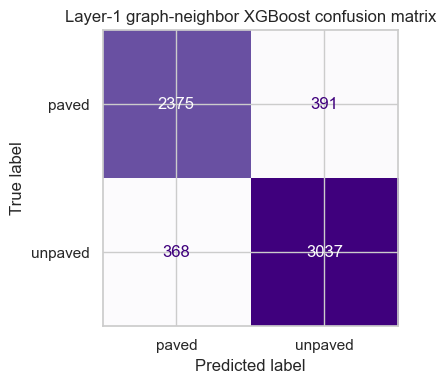

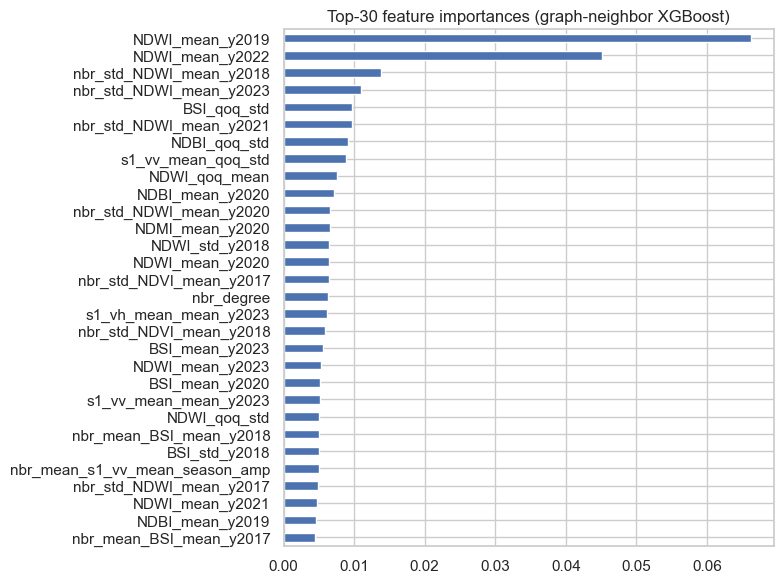

Top-20 important features (graph-neighbor XGBoost):


,importance
NDWI_mean_y2019,0.066189
NDWI_mean_y2022,0.045170
nbr_std_NDWI_mean_y2018,0.013828
nbr_std_NDWI_mean_y2023,0.010954
BSI_qoq_std,0.009764
nbr_std_NDWI_mean_y2021,0.009673
NDBI_qoq_std,0.009120
s1_vv_mean_qoq_std,0.008784
NDWI_qoq_mean,0.007514
NDBI_mean_y2020,0.007206


In [13]:
# ---- XGBoost on graph-neighbor extension (same split for direct comparison) ----
from sklearn.model_selection import GroupKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

if 'rf_graph' not in globals() or 'feature_cols_graph' not in globals():
    raise ValueError('Run section 7 (graph-neighbor RF) first to create rf_graph/feature_cols_graph.')

# Recreate the same split recipe used in graph-neighbor RF
Xg = rf_graph[feature_cols_graph].copy()
yg = rf_graph['layer1_label_large'].copy()

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42, stratify=yg
)

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError('xgboost is not installed. Install with: pip install xgboost') from e

label_map = {'paved': 0, 'unpaved': 1}
inv_label_map = {0: 'paved', 1: 'unpaved'}

yg_train_num = yg_train.map(label_map)
yg_test_num = yg_test.map(label_map)

# Handle imbalance with scale_pos_weight
neg = int((yg_train_num == 0).sum())
pos = int((yg_train_num == 1).sum())
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(Xg_train, yg_train_num)
pred_num = xgb_model.predict(Xg_test)
pred_lbl = pd.Series(pred_num).map(inv_label_map).values

print('XGBoost report (graph-neighbor features):')
print(classification_report(yg_test, pred_lbl, digits=3))

cmx = confusion_matrix(yg_test, pred_lbl, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cmx, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Layer-1 graph-neighbor XGBoost confusion matrix')
plt.tight_layout()
plt.show()

impx = pd.Series(xgb_model.feature_importances_, index=feature_cols_graph).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
impx.head(30).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-30 feature importances (graph-neighbor XGBoost)')
plt.tight_layout()
plt.show()

print('Top-20 important features (graph-neighbor XGBoost):')
display(impx.head(20).to_frame('importance'))



## 8) Grouped CV + Model Benchmark (After Neighbor Features)

Evaluate leakage-robust performance with grouped cross-validation and compare `RandomForest`, `LogisticRegression`, and `XGBoost` (if installed).

Using dataframe: rf_graph (30,851 rows)
S1 VV columns available: ['s1_vv_mean_mean_y2017', 's1_vv_mean_mean_y2018', 's1_vv_mean_mean_y2019', 's1_vv_mean_mean_y2020', 's1_vv_mean_mean_y2021', 's1_vv_mean_mean_y2022', 's1_vv_mean_mean_y2023', 's1_vv_minus_vh_mean_mean_y2017', 's1_vv_minus_vh_mean_mean_y2018', 's1_vv_minus_vh_mean_mean_y2019', 's1_vv_minus_vh_mean_mean_y2020', 's1_vv_minus_vh_mean_mean_y2021', 's1_vv_minus_vh_mean_mean_y2022', 's1_vv_minus_vh_mean_mean_y2023', 's1_vv_std_mean_y2017', 's1_vv_std_mean_y2018', 's1_vv_std_mean_y2019', 's1_vv_std_mean_y2020', 's1_vv_std_mean_y2021', 's1_vv_std_mean_y2022', 's1_vv_std_mean_y2023', 's1_vv_minus_vh_std_mean_y2017', 's1_vv_minus_vh_std_mean_y2018', 's1_vv_minus_vh_std_mean_y2019', 's1_vv_minus_vh_std_mean_y2020', 's1_vv_minus_vh_std_mean_y2021', 's1_vv_minus_vh_std_mean_y2022', 's1_vv_minus_vh_std_mean_y2023', 's1_vv_mean_std_y2017', 's1_vv_mean_std_y2018', 's1_vv_mean_std_y2019', 's1_vv_mean_std_y2020', 's1_vv_mean_std_y2021', 's

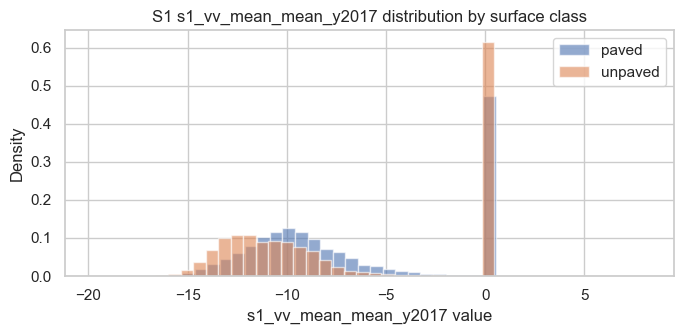

In [15]:
# ---- Sentinel-1 diagnostic: mean VV backscatter by surface class ----
# Contextualises why Stage 3 (S2 + S1) may under- or over-perform the S2-only model.
# This cell can be run before or after the grouped-CV benchmark.

candidate_frames = []
for frame_name in ['bench_df', 'rf_graph', 'rf_temporal', 'road_feats_multi', 'road_feats_large']:
    if frame_name in globals():
        frame = globals()[frame_name]
        if isinstance(frame, pd.DataFrame) and 'layer1_label_large' in frame.columns:
            candidate_frames.append((frame_name, frame))

if not candidate_frames:
    raise NameError(
        'No labelled S1 feature dataframe found. Run the multi-year / temporal feature cells first.'
    )

diag_name, diag_df = candidate_frames[0]
print(f'Using dataframe: {diag_name} ({len(diag_df):,} rows)')

s1_col_candidates = [
    c for c in diag_df.columns
    if ('VV' in c.upper() or 'S1_VV' in c.upper()) and pd.api.types.is_numeric_dtype(diag_df[c])
]
print('S1 VV columns available:', s1_col_candidates)

if s1_col_candidates:
    preferred = [c for c in s1_col_candidates if 'MEAN' in c.upper()]
    vv_col = preferred[0] if preferred else s1_col_candidates[0]
    vv_by_class = diag_df.groupby('layer1_label_large')[vv_col].mean()
    print(f'\nMean {vv_col} by surface class (dB proxy):')
    print(vv_by_class.round(4).to_string())
    gap = abs(vv_by_class.get('paved', 0) - vv_by_class.get('unpaved', 0))
    print(f'\nPaved vs unpaved VV gap: {gap:.4f} dB')
    if gap < 0.5:
        print('→ Small gap — S1 VV adds limited discriminative power for paved/unpaved classification.')
    else:
        print('→ Meaningful gap — S1 VV carries useful surface-type signal.')

    fig, ax = plt.subplots(figsize=(7, 3.5))
    for cls, grp in diag_df.groupby('layer1_label_large'):
        ax.hist(grp[vv_col].dropna(), bins=40, alpha=0.6, label=cls, density=True)
    ax.set_xlabel(f'{vv_col} value')
    ax.set_ylabel('Density')
    ax.set_title(f'S1 {vv_col} distribution by surface class')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No numeric VV column found. Check that S1 features were included in the current feature table.')


In [16]:
# ---- Grouped CV benchmark on graph-neighbor feature set ----
# Uses rf_graph (features + labels) from section 7.
from sklearn.model_selection import GroupKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

if 'rf_graph' not in globals():
    raise ValueError('rf_graph not found. Run section 7 (graph neighbors) first.')

bench_df = rf_graph.copy()
bench_df['osm_id'] = bench_df['osm_id'].astype(str)

# Build group ids to reduce leakage: prefer road name from roads_osm, fallback to osm_id.
name_lookup = roads_osm[['osm_id', 'name']].copy()
name_lookup['osm_id'] = name_lookup['osm_id'].astype(str)
name_lookup['name_clean'] = name_lookup['name'].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
name_lookup = name_lookup[['osm_id', 'name_clean']].drop_duplicates(subset=['osm_id'])

bench_df = bench_df.merge(name_lookup, on='osm_id', how='left')
bench_df['group_id'] = np.where(bench_df['name_clean'].notna(), 'name::' + bench_df['name_clean'].astype(str), 'osm::' + bench_df['osm_id'])

feature_cols_bench = [c for c in bench_df.columns if c not in ['osm_id', 'layer1_label_large', 'name_clean', 'group_id']]
Xb = bench_df[feature_cols_bench].apply(pd.to_numeric, errors='coerce').fillna(0)
yb = bench_df['layer1_label_large'].copy()
groups = bench_df['group_id'].copy()

print('Benchmark rows:', len(bench_df))
print('Unique groups:', groups.nunique())
print('Class balance (%):')
print(yb.value_counts(normalize=True).mul(100).round(2))

# Model factory
models = {
    'rf': RandomForestClassifier(
        n_estimators=900,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight='balanced_subsample',
    ),
    'logistic': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            random_state=42,
            class_weight='balanced',
            max_iter=3000,
        )),
    ]),
}

# XGBoost optional
xgb_available = True
try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False

if xgb_available:
    models['xgboost'] = XGBClassifier(
        n_estimators=700,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
else:
    print('XGBoost not installed; skipping xgboost model in benchmark.')


if lgbm_available:
    models['lightgbm'] = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=42, n_jobs=-1, verbose=-1,
    )

# Encode labels once for xgboost compatibility if needed
label_map = {'unpaved': 1, 'paved': 0}
inv_label_map = {v: k for k, v in label_map.items()}

cv = GroupKFold(n_splits=5)
rows = []

for model_name, model in models.items():
    fold_no = 0
    for tr_idx, te_idx in cv.split(Xb, yb, groups=groups):
        fold_no += 1
        Xtr, Xte = Xb.iloc[tr_idx], Xb.iloc[te_idx]
        ytr, yte = yb.iloc[tr_idx], yb.iloc[te_idx]

        if model_name == 'xgboost':
            ytr_num = ytr.map(label_map)
            yte_num = yte.map(label_map)
            model.fit(Xtr, ytr_num)
            pred_num = model.predict(Xte)
            pred = pd.Series(pred_num).map(inv_label_map).values
            yt = yte.values
        else:
            model.fit(Xtr, ytr)
            pred = model.predict(Xte)
            yt = yte.values

        p, r, f1, sup = precision_recall_fscore_support(
            yt, pred, labels=['paved', 'unpaved'], zero_division=0
        )
        acc = accuracy_score(yt, pred)
        mcc = matthews_corrcoef(yt, pred)

        rows.append({
            'model': model_name,
            'fold': fold_no,
            'accuracy': acc,
            'paved_precision': p[0],
            'paved_recall': r[0],
            'paved_f1': f1[0],
            'unpaved_precision': p[1],
            'unpaved_recall': r[1],
            'unpaved_f1': f1[1],
            'macro_f1': (f1[0] + f1[1]) / 2.0,
            'mcc': mcc,
        })

cv_results = pd.DataFrame(rows)

summary = (
    cv_results.groupby('model', as_index=False)
    .agg(
        accuracy_mean=('accuracy','mean'), accuracy_std=('accuracy','std'),
        paved_f1_mean=('paved_f1','mean'), paved_f1_std=('paved_f1','std'),
        unpaved_f1_mean=('unpaved_f1','mean'), unpaved_f1_std=('unpaved_f1','std'),
        macro_f1_mean=('macro_f1','mean'), macro_f1_std=('macro_f1','std'),
        paved_recall_mean=('paved_recall','mean'),
        unpaved_recall_mean=('unpaved_recall','mean'),
    )
    .sort_values('macro_f1_mean', ascending=False)
)

print('Fold-by-fold results:')
display(cv_results.sort_values(['model','fold']))
print('Grouped CV summary (mean ± std):')
display(summary)

# Store Stage 3 per-fold RF macro-F1 for Wilcoxon test
stage3_f1s = cv_results[cv_results['model'] == 'rf']['macro_f1'].tolist()


Benchmark rows: 30851
Unique groups: 25365
Class balance (%):
layer1_label_large
unpaved    55.17
paved      44.83
Name: proportion, dtype: float64
Fold-by-fold results:


,model,fold,accuracy,paved_precision,paved_recall,paved_f1,unpaved_precision,unpaved_recall,unpaved_f1,macro_f1,mcc
15,lightgbm,1,0.874413,0.880758,0.839292,0.859525,0.869503,0.904065,0.886447,0.872986,0.746801
16,lightgbm,2,0.874878,0.863177,0.858836,0.861001,0.884412,0.888069,0.886236,0.873619,0.747247
17,lightgbm,3,0.877472,0.862796,0.858352,0.860568,0.888921,0.892526,0.890720,0.875644,0.751297
18,lightgbm,4,0.876499,0.878512,0.839623,0.858627,0.875000,0.906268,0.890360,0.874493,0.749692
19,lightgbm,5,0.868882,0.863193,0.838369,0.850600,0.873215,0.893368,0.883177,0.866889,0.734069
5,logistic,1,0.835197,0.813019,0.831150,0.821985,0.854706,0.838613,0.846583,0.834284,0.668744
6,logistic,2,0.832901,0.791487,0.854885,0.821965,0.872273,0.814826,0.842571,0.832268,0.666729
7,logistic,3,0.833387,0.796076,0.835909,0.815506,0.865501,0.831402,0.848109,0.831807,0.664437
8,logistic,4,0.836143,0.810167,0.826923,0.818459,0.857909,0.843585,0.850687,0.834573,0.669291
9,logistic,5,0.832415,0.801054,0.829632,0.815093,0.859248,0.834648,0.846769,0.830931,0.662288


Grouped CV summary (mean ± std):


,model,accuracy_mean,accuracy_std,paved_f1_mean,paved_f1_std,unpaved_f1_mean,unpaved_f1_std,macro_f1_mean,macro_f1_std,paved_recall_mean,unpaved_recall_mean
3,xgboost,0.876179,0.002135,0.860109,0.002875,0.888919,0.002237,0.874514,0.002169,0.849283,0.898088
0,lightgbm,0.874429,0.003336,0.858064,0.004274,0.887388,0.003157,0.872726,0.003412,0.846894,0.896859
2,rf,0.855661,0.005366,0.834907,0.005999,0.871767,0.005054,0.853337,0.005393,0.814244,0.889419
1,logistic,0.834009,0.001590,0.818602,0.003342,0.846944,0.002943,0.832773,0.001589,0.835700,0.832615


In [17]:
# ---- Wilcoxon signed-rank test: Stage 3 (S2 + S1) vs Stage 1 (S2) ----
# stage3_f1s collected above.
# stage1_f1s must be set from testlayer1.ipynb CV output.
# Example: stage2_f1s = [0.85, 0.87, 0.86, 0.84, 0.88]


stage1_f1s = [0.848814, 0.859067, 0.847317, 0.847683, 0.862072]
print('Stage 3 (S2 + S1 + fclass) per-fold macro-F1:', [round(v,4) for v in stage3_f1s])

if 'stage1_f1s' not in globals():
    print()
    print('stage1_f1s not found in globals.')
    print('Copy the RF per-fold macro-F1 values from layer1.ipynb and set:')
    print('  stage1_f1s = [f1_fold1, f1_fold2, f1_fold3, f1_fold4, f1_fold5]')
    print('Then re-run this cell.')
elif len(stage1_f1s) != len(stage3_f1s):
    print(f'Length mismatch: stage1={len(stage1_f1s)}, stage3={len(stage3_f1s)}.')
else:
    stat, p = wilcoxon(stage3_f1s, stage1_f1s, alternative='greater')
    print('Stage 1 (S2)       per-fold macro-F1:', [round(v,4) for v in stage1_f1s])
    delta = np.mean(stage3_f1s) - np.mean(stage1_f1s)
    print(f'\nMean delta (Stage3 - Stage1): {delta:+.4f}')
    print(f'Wilcoxon statistic: {stat:.4f}')
    print(f'p-value (one-sided, Stage3 > Stage1): {p:.4f}')
    if p < 0.05:
        print('→ S1 addition significantly improves over Stage 1 (p < 0.05).')
    else:
        print('→ S1 addition does NOT significantly improve over Stage 1 (p ≥ 0.05).')
        print('  This supports the claim that S1 adds noise rather than signal.')


Stage 3 (S2 + S1 + fclass) per-fold macro-F1: [0.8575, 0.8481, 0.8596, 0.8538, 0.8476]
Stage 1 (S2)       per-fold macro-F1: [0.8488, 0.8591, 0.8473, 0.8477, 0.8621]

Mean delta (Stage3 - Stage1): +0.0003
Wilcoxon statistic: 7.0000
p-value (one-sided, Stage3 > Stage1): 0.5938
→ S1 addition does NOT significantly improve over Stage 1 (p ≥ 0.05).
  This supports the claim that S1 adds noise rather than signal.
